# Milestone 2 — three hexes, looked at up close

Section 9 of `m2_hex_table.ipynb` picked the three hexes where the trend line and end-minus-start
disagree most. Numbers alone made them look random. This notebook asks what each piece of ground
actually *is*, and whether its numbers follow from what happened on it.

| | hex | why it was picked |
|---|---|---|
| A | `8860169631fffff` | "cleared in the last year" — end-minus-start ranks it 20th, trend line 42nd |
| B | `88601696e3fffff` | "cleared in the middle" — trend line ranks it 38th, end-minus-start 72nd |
| C | `8861892501fffff` | "jumpy" — end-minus-start calls it the 10th-largest loss, trend line 48th |

**Caution before reading anything into these:** they were chosen *because* the two measures disagree
on them most. They are the extreme cases by construction, so they explain themselves, not the whole
method.

For each hex, in order:

1. **Where it is** — a satellite-map link, and what OpenStreetMap says covers the ground (by area)
2. **Raw and normalised lines** — does the jump belong to the hex, or to the subtraction?
3. **The photos** — the exact Feb–Mar median composite each year, hex outlined
4. **Inside each season** — every individual satellite pass, to see whether the yearly number is
   stable or depends on which days were cloudy

**Needs Earth Engine** (sections 3 and 4) and the Overpass API (section 1, cached after the first run
in `data/deep_dive_osm_*.json`). Run with `EE_PROJECT` set, as for `m1_spot_check.ipynb`.

In [1]:
import io
import json
import os
import socket
import time
import urllib.parse
import urllib.request
from pathlib import Path

import ee
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import LineString, Polygon, shape
from shapely.ops import polygonize, unary_union
from shapely.validation import make_valid

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)

METRIC = "EPSG:32643"
COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
INK, MUTED = "#2b2b2b", "#8a8a8a"
LOSS, WET, CITY = "#8c2d04", "#2c7fb8", "#8a8a8a"
RGB_MAX = 3000
NDVI_RANGE = (-0.2, 0.8)
NDVI_PALETTE = ["#8c510a", "#d8b365", "#f6e8c3", "#c7eae5", "#5ab4ac", "#01665e"]
CLOUD_SCL = (3, 8, 9, 10)

HEXES = {
    "A": "8860169631fffff",
    "B": "88601696e3fffff",
    "C": "8861892501fffff",
}

table = pd.read_csv("results/m2_hex_table.csv")
water_ids = set(pd.read_csv("results/m2_water_hexes.csv").h3)
kept = table[~table.h3.isin(water_ids)]
green = kept.pivot(index="h3", columns="year", values="green")
wet = table.pivot(index="h3", columns="year", values="wet")
YEARS = list(green.columns)
city = green.mean(axis=0)
norm = green.sub(city, axis=1)

socket.setdefaulttimeout(180)
ee.Initialize(project=os.environ["EE_PROJECT"])
print(f"{len(green):,} hexes, {YEARS[0]}-{YEARS[-1]}; Earth Engine ready")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


2,818 hexes, 2019-2026; Earth Engine ready


---
## 1 — Where each hex is, and what covers it

The link opens Google Maps in satellite view at the hex centre. Each hex is about 0.76 km², roughly
950 m across, so the view at zoom 16 shows about the whole hex.

The table underneath is OpenStreetMap's land-use polygons clipped to the hex, as a **share of the
hex's area** (measured in metres, not degrees). Classes can overlap — a lake inside a residential
zone counts in both — so the column does not sum to 100%. Unmapped ground is simply absent.

In [2]:
UA = {"User-Agent": "bangalore-blue-green personal research"}
KEYS = ("landuse", "natural", "leisure", "water", "man_made", "aeroway", "amenity")


def hex_polygon(hx):
    return Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(hx)])


def ask_overpass(query):
    for attempt in range(4):
        try:
            req = urllib.request.Request("https://overpass.kumi.systems/api/interpreter",
                                         data=urllib.parse.urlencode({"data": query}).encode(),
                                         headers=UA)
            return json.load(urllib.request.urlopen(req, timeout=180))
        except Exception as exc:
            print(f"  overpass attempt {attempt + 1} failed: {exc}")
            time.sleep(20)
    raise RuntimeError("overpass unavailable")


def overpass(hx):
    cache = Path(f"data/deep_dive_osm_{hx}.json")
    if cache.exists():
        data = json.loads(cache.read_text())
    else:
        poly = " ".join(f"{lat} {lng}" for lat, lng in h3.cell_to_boundary(hx))
        parts = "".join(f'{kind}(poly:"{poly}")[{key}];' for kind in ("way", "relation") for key in KEYS)
        data = ask_overpass(f"[out:json][timeout:120];({parts});out geom tags;")
    bare = [el for el in data["elements"]
            if el["type"] == "relation" and not el.get("members") and "geojson" not in el]
    if bare:
        ids = ",".join(f"R{el['id']}" for el in bare)
        url = f"https://nominatim.openstreetmap.org/lookup?osm_ids={ids}&format=json&polygon_geojson=1"
        found = {int(r["osm_id"]): r["geojson"]
                 for r in json.load(urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=60))}
        for el in bare:
            if el["id"] in found:
                el["geojson"] = found[el["id"]]
    cache.write_text(json.dumps(data))
    return data


def element_polygon(el):
    if "geojson" in el:
        return make_valid(shape(el["geojson"]))
    if el["type"] == "way":
        pts = [(p["lon"], p["lat"]) for p in el.get("geometry", [])]
        return make_valid(Polygon(pts)) if len(pts) >= 4 and pts[0] == pts[-1] else None
    lines = [LineString([(p["lon"], p["lat"]) for p in m["geometry"]])
             for m in el.get("members", []) if m.get("role") == "outer" and m.get("geometry")]
    polys = list(polygonize(unary_union(lines))) if lines else []
    return make_valid(unary_union(polys)) if polys else None


def cover(hx):
    rows = []
    for el in overpass(hx)["elements"]:
        geom = element_polygon(el)
        if geom is None:
            continue
        tags = el.get("tags", {})
        label = next((f"{k}={tags[k]}" for k in KEYS if k in tags), None)
        if label:
            rows.append({"class": label, "name": tags.get("name", ""), "geometry": geom})
    frame = gpd.GeoDataFrame(rows, crs="EPSG:4326").to_crs(METRIC)
    hexagon = gpd.GeoSeries([hex_polygon(hx)], crs="EPSG:4326").to_crs(METRIC).iloc[0]
    frame["share"] = frame.geometry.intersection(hexagon).area / hexagon.area
    frame = frame[frame.share > 0.005]
    by_class = frame.dissolve(by="class").geometry.intersection(hexagon).area / hexagon.area
    names = frame.groupby("class").name.apply(lambda s: ", ".join(sorted({n for n in s if n}))[:70])
    return pd.DataFrame({"share of hex": by_class.map("{:.0%}".format), "named": names}) \
        .loc[by_class.sort_values(ascending=False).index]


for tag, hx in HEXES.items():
    lat, lng = h3.cell_to_latlng(hx)
    print(f"\n{tag}  {hx}   centre {lat:.5f}, {lng:.5f}")
    print(f"   https://www.google.com/maps/@{lat:.5f},{lng:.5f},16z/data=!3m1!1e3")
    print(cover(hx).to_string())


A  8860169631fffff   centre 13.11324, 77.55895
   https://www.google.com/maps/@13.11324,77.55895,16z/data=!3m1!1e3
                     share of hex                                             named
class                                                                              
landuse=residential           26%  Ajmera Lakeside Paradise, GK Lakeview Apartments
natural=scrub                 16%                                                  
natural=water                 15%                                        Attur Lake
landuse=construction           5%                    Ajmera Lakeside Paradise (u/c)
natural=wetland                2%                                                  
leisure=park                   2%                                                  
leisure=garden                 2%                                     Attur Nursery
amenity=hospital               1%                           NIKISA Dementia Village
amenity=college                1%           

---
## 2 — Raw and normalised, side by side

**Left:** the hex's greenness as measured (black) against the city average (grey). If the hex's jumps
were the city's weather leaking through, the two lines would move together.

**Middle:** the same hex after subtracting the city — the number the ranking uses.

**Right:** the wetness index for the same hex. Water pulls it up; so does bare, cleared soil to a
smaller degree, so a rise here is a hint, not proof.

A: hex swings 0.191 raw, city swings 0.064; biggest one-year move 0.109 (2026)
B: hex swings 0.178 raw, city swings 0.064; biggest one-year move 0.176 (2024)
C: hex swings 0.205 raw, city swings 0.064; biggest one-year move 0.205 (2025)


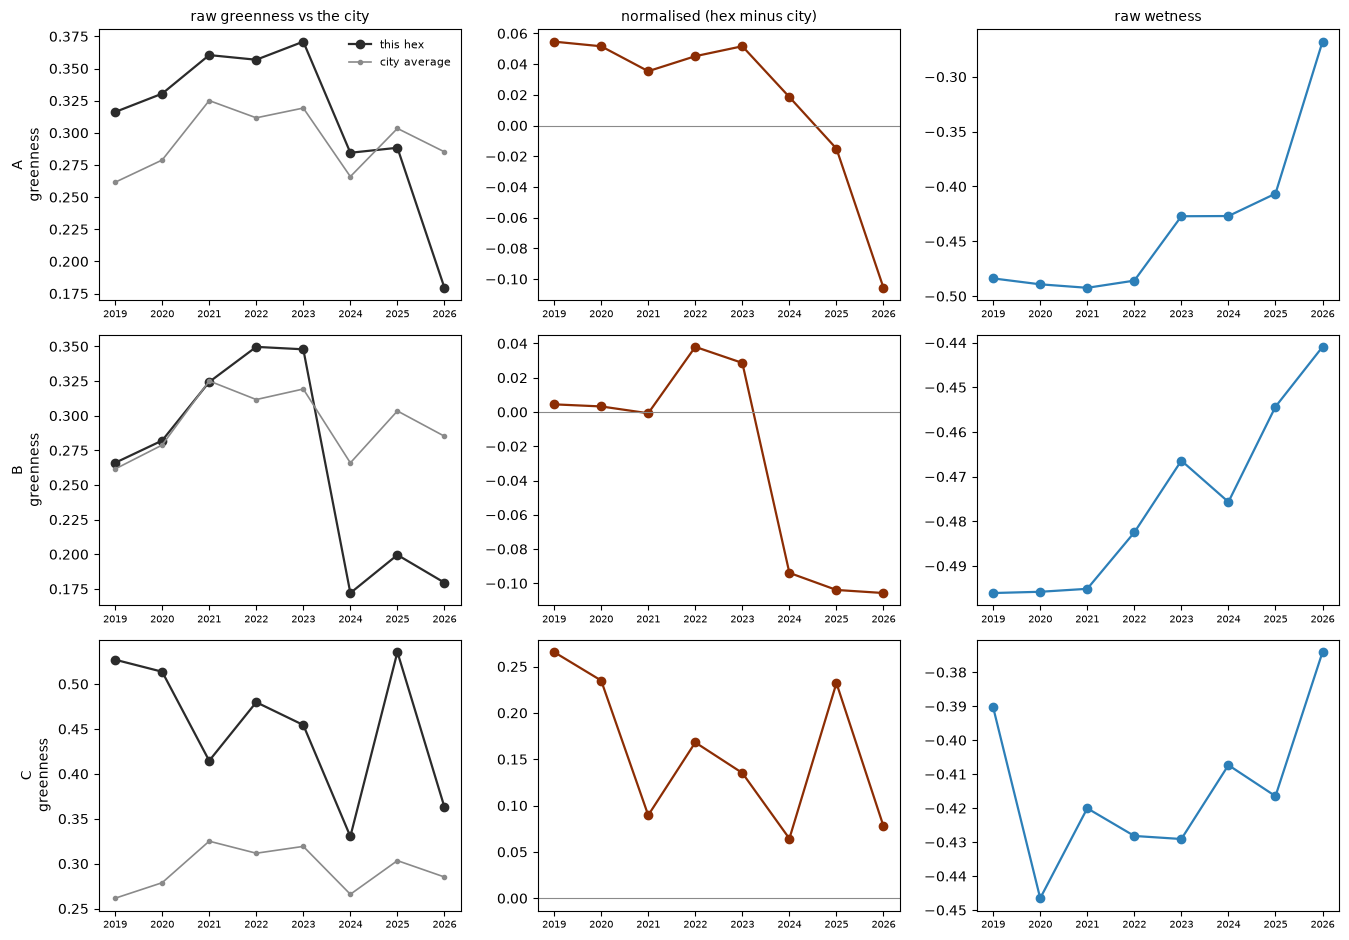

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(13.5, 9.5))
for row, (tag, hx) in zip(axes, HEXES.items()):
    raw, rel, w = green.loc[hx], norm.loc[hx], wet.loc[hx]
    row[0].plot(YEARS, raw, "o-", color=INK, linewidth=1.6, label="this hex")
    row[0].plot(YEARS, city, "o-", color=CITY, linewidth=1.2, markersize=3, label="city average")
    row[0].set_ylabel(f"{tag}\ngreenness")
    row[1].plot(YEARS, rel, "o-", color=LOSS, linewidth=1.6)
    row[1].axhline(0, color=MUTED, linewidth=0.8)
    row[2].plot(YEARS, w, "o-", color=WET, linewidth=1.6)
    for ax in row:
        ax.set_xticks(YEARS)
        ax.set_xticklabels(YEARS, fontsize=7)
    print(f"{tag}: hex swings {raw.max() - raw.min():.3f} raw, city swings {city.max() - city.min():.3f}; "
          f"biggest one-year move {raw.diff().abs().max():.3f} ({raw.diff().abs().idxmax()})")
axes[0][0].legend(fontsize=8, frameon=False)
axes[0][0].set_title("raw greenness vs the city", fontsize=10)
axes[0][1].set_title("normalised (hex minus city)", fontsize=10)
axes[0][2].set_title("raw wetness", fontsize=10)
plt.tight_layout(); plt.show()

---
## 2b — How much of each hex is open water, year by year

OpenStreetMap says where a lake is *meant* to be. This counts where water actually *was* each dry
season: the share of the hex's 10 m pixels whose wetness index is above zero, which is open water.

For A, the last lines split the greenness drop into two parts: the pixels that *became* water between
the two years, and everything else. The two parts add up to the hex's total change.

In [4]:
def hex_geom(hx):
    return ee.Geometry.Polygon([[[lng, lat] for lat, lng in h3.cell_to_boundary(hx)]])


def composite(year, region):
    return (ee.ImageCollection(COLLECTION).filterBounds(region)
            .filterDate(f"{year}-02-01", f"{year}-03-31").median())


def is_water(image):
    return image.normalizedDifference(["B3", "B11"]).gt(0)


water_share = pd.DataFrame({
    tag: [is_water(composite(y, hex_geom(hx))).reduceRegion(ee.Reducer.mean(), hex_geom(hx), 10)
          .values().get(0).getInfo() for y in YEARS]
    for tag, hx in HEXES.items()
}, index=YEARS)
print("share of each hex that is open water, by year")
print(water_share.map("{:.1%}".format).T.to_string())

geom = hex_geom(HEXES["A"])
for y0, y1 in ((YEARS[-2], YEARS[-1]), (YEARS[0], YEARS[-1])):
    c0, c1 = composite(y0, geom), composite(y1, geom)
    change = c1.normalizedDifference(["B8", "B4"]).subtract(c0.normalizedDifference(["B8", "B4"]))
    became_water = is_water(c1).And(is_water(c0).Not())
    r = (change.rename("total")
         .addBands(change.multiply(became_water).rename("water"))
         .addBands(change.multiply(became_water.Not()).rename("rest"))
         .addBands(became_water.rename("share"))
         .reduceRegion(ee.Reducer.mean(), geom, 10).getInfo())
    print(f"\nA, {y0} -> {y1}: greenness change {r['total']:+.3f}")
    print(f"   from pixels that became water ({r['share']:.1%} of the hex): {r['water']:+.3f}"
          f"  ({r['water'] / r['total']:.0%} of the change)")
    print(f"   from everything else:                          {r['rest']:+.3f}")

share of each hex that is open water, by year
   2019  2020  2021  2022  2023  2024  2025   2026
A  0.0%  0.0%  0.1%  0.0%  2.4%  1.8%  2.5%  14.1%
B  0.2%  0.3%  0.6%  0.9%  2.4%  2.0%  3.0%   0.8%
C  0.6%  0.2%  0.3%  0.7%  0.4%  0.0%  0.6%   3.1%



A, 2025 -> 2026: greenness change -0.109
   from pixels that became water (11.7% of the hex): -0.097  (89% of the change)
   from everything else:                          -0.012



A, 2019 -> 2026: greenness change -0.137
   from pixels that became water (14.1% of the hex): -0.074  (54% of the change)
   from everything else:                          -0.063


---
## 3 — The photos, every year

Each frame is the same Feb–Mar median composite `measure_hexes.py` averaged, with the hex outlined in
yellow and a 300 m margin around it for context. Top row true colour, bottom row greenness (brown =
bare or built, teal = dense vegetation), both on a fixed scale so years compare by eye.

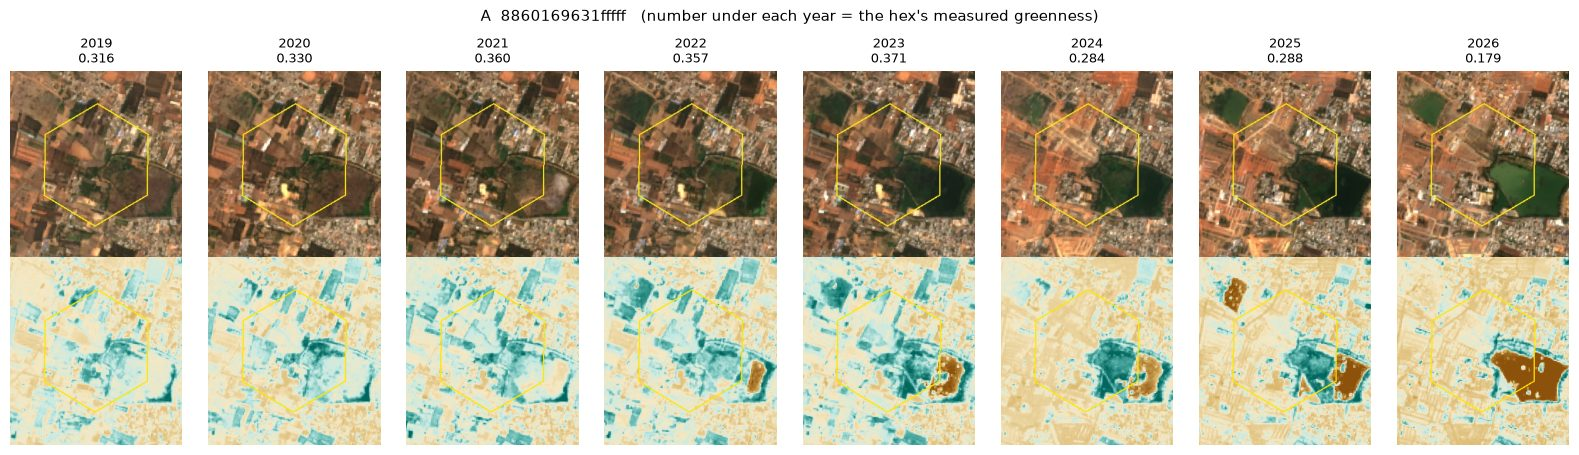

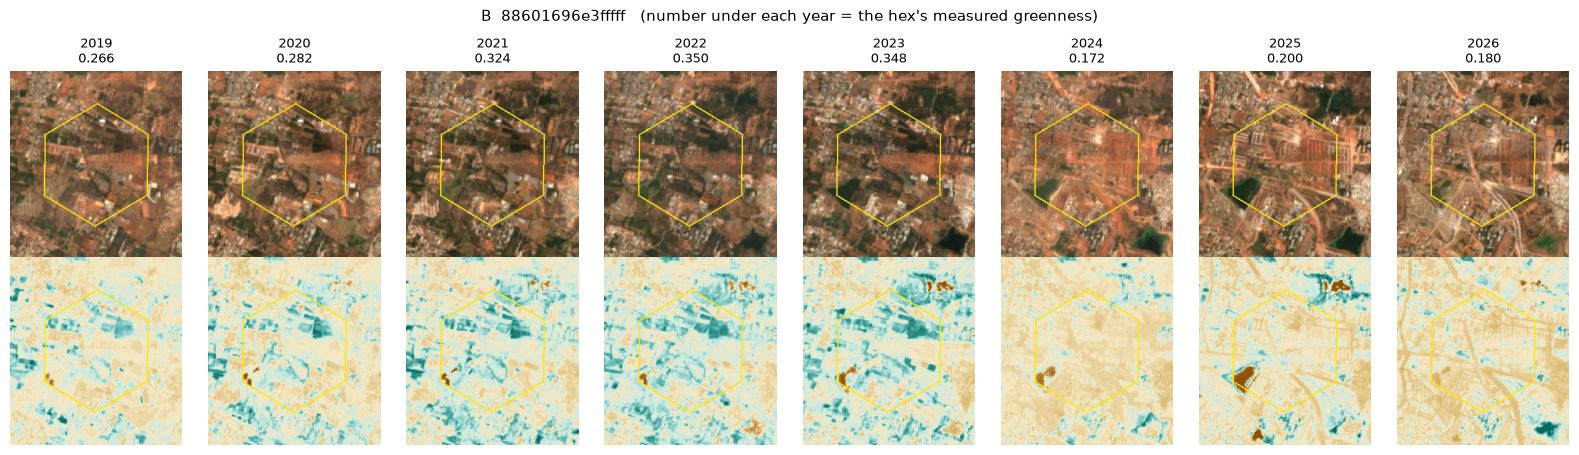

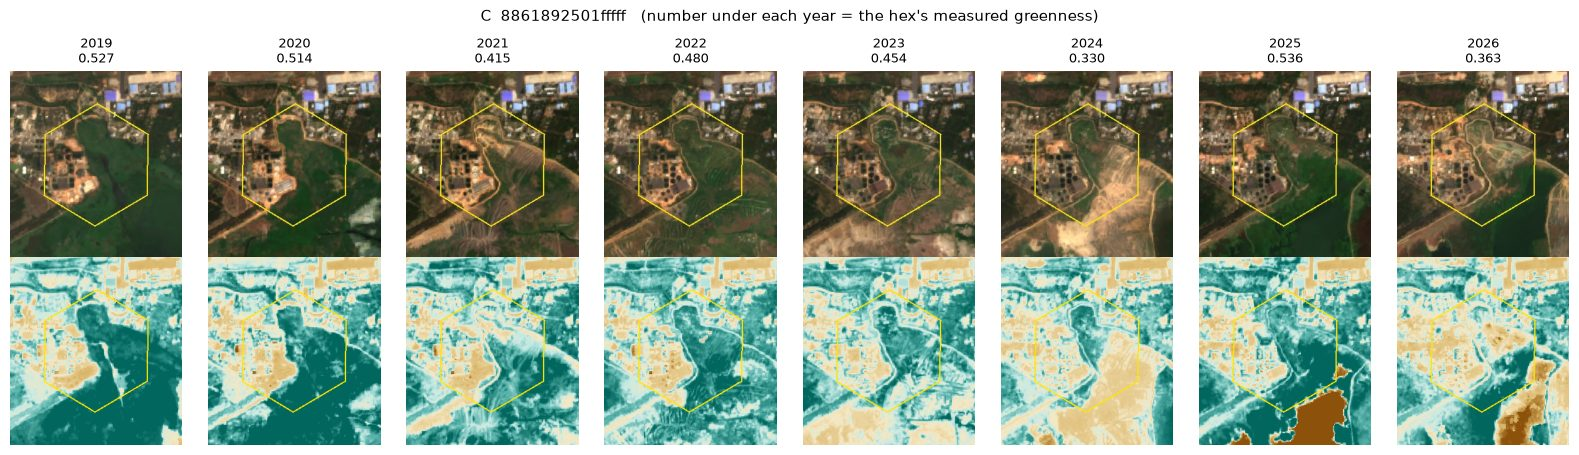

In [5]:
def thumb(image, box, fmt):
    url = image.getThumbURL({"region": box, "dimensions": 300, "format": fmt})
    return plt.imread(io.BytesIO(urllib.request.urlopen(url).read()), format=fmt)


for tag, hx in HEXES.items():
    geom = hex_geom(hx)
    box = geom.buffer(300).bounds()
    edge = ee.Image().byte().paint(ee.FeatureCollection([ee.Feature(geom)]), 1, 2) \
        .selfMask().visualize(palette=["#ffe600"])
    fig, axes = plt.subplots(2, len(YEARS), figsize=(16, 4.6))
    for i, year in enumerate(YEARS):
        comp = composite(year, box)
        rgb = comp.visualize(bands=["B4", "B3", "B2"], min=0, max=RGB_MAX).blend(edge)
        ndvi = comp.normalizedDifference(["B8", "B4"]).visualize(
            min=NDVI_RANGE[0], max=NDVI_RANGE[1], palette=NDVI_PALETTE).blend(edge)
        axes[0][i].imshow(thumb(rgb, box, "jpg"))
        axes[1][i].imshow(thumb(ndvi, box, "png"))
        axes[0][i].set_title(f"{year}\n{green.loc[hx, year]:.3f}", fontsize=9)
        for ax in axes[:, i]:
            ax.set_axis_off()
    fig.suptitle(f"{tag}  {hx}   (number under each year = the hex's measured greenness)", fontsize=11)
    plt.tight_layout(); plt.show()

---
## 4 — Inside each season: every satellite pass

The yearly number is the median of every Feb–Mar pass, with **no cloud masking** — `measure_hexes.py`
has none, and relies on the median to outvote cloudy days. This checks whether that holds for these
hexes.

Each dot is one pass: the hex's average greenness that day, coloured by how much of the hex the
satellite's own cloud flag marks as cloud or cloud shadow. Passes that cover less than 90% of the hex
(a tile edge) are dropped. The black bar is the value stored in the hex table; the teal bar is the
median of the clear passes only (under 5% cloud).

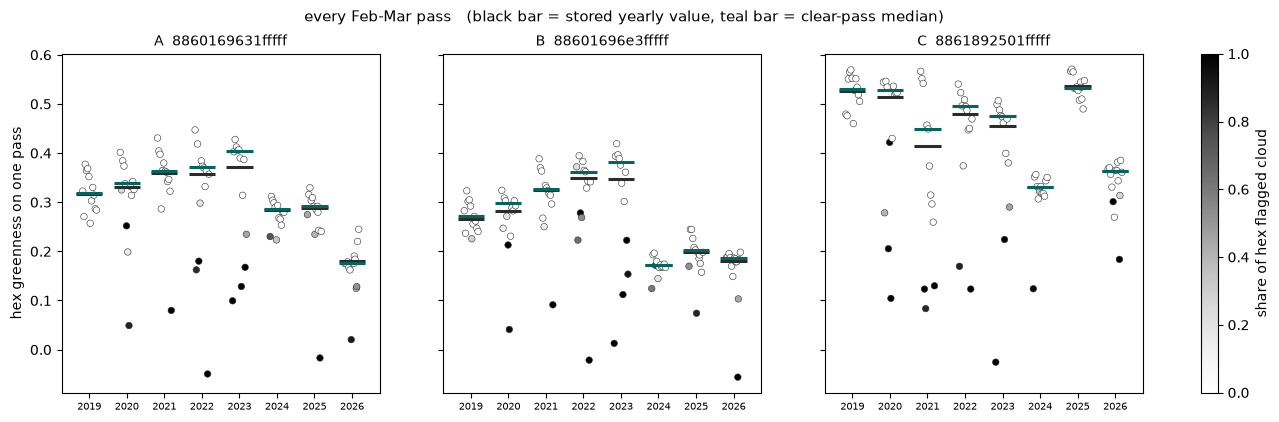


A  8860169631fffff
      passes  clear  stored  clear median  clear spread
year                                                   
2019      12     12   0.316         0.319         0.120
2020      12      8   0.330         0.340         0.088
2021      12     11   0.360         0.363         0.144
2022      12      8   0.357         0.371         0.115
2023      12      8   0.371         0.404         0.114
2024      12     10   0.284         0.285         0.059
2025      13     10   0.288         0.292         0.089
2026      14     11   0.179         0.177         0.083

B  88601696e3fffff
      passes  clear  stored  clear median  clear spread
year                                                   
2019      12     11   0.266         0.271         0.086
2020      12      8   0.282         0.298         0.094
2021      12     10   0.324         0.327         0.121
2022      12      7   0.350         0.362         0.066
2023      12      8   0.348         0.382         0.118
2024    

In [6]:
def passes(hx):
    geom = hex_geom(hx)
    full = ee.Image.constant(1).reduceRegion(ee.Reducer.count(), geom, 10).values().get(0)

    def one(img):
        scl = img.select("SCL")
        cloud = scl.eq(CLOUD_SCL[0])
        for code in CLOUD_SCL[1:]:
            cloud = cloud.Or(scl.eq(code))
        stats = (img.normalizedDifference(["B8", "B4"]).rename("ndvi")
                 .addBands(cloud.rename("cloud"))
                 .reduceRegion(ee.Reducer.mean().combine(ee.Reducer.count(), sharedInputs=True),
                               geom, 10))
        return ee.Feature(None, stats.set("date", img.date().format("YYYY-MM-dd")).set("full", full))

    rows = []
    for year in YEARS:
        col = (ee.ImageCollection(COLLECTION).filterBounds(geom)
               .filterDate(f"{year}-02-01", f"{year}-03-31"))
        for f in col.map(one).getInfo()["features"]:
            p = f["properties"]
            rows.append({"year": year, "date": p["date"], "ndvi": p.get("ndvi_mean"),
                         "cloud": p.get("cloud_mean"), "coverage": p["ndvi_count"] / p["full"]})
    frame = pd.DataFrame(rows).dropna()
    return frame[frame.coverage >= 0.9]


scene = {tag: passes(hx) for tag, hx in HEXES.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, (tag, hx) in zip(axes, HEXES.items()):
    s = scene[tag]
    dots = ax.scatter(s.year + (pd.to_datetime(s.date).dt.dayofyear - 60) / 150, s.ndvi,
                      c=s.cloud, cmap="Greys", vmin=0, vmax=1, edgecolors=INK, linewidths=0.4, s=22)
    clear = s[s.cloud < 0.05].groupby("year").ndvi.median()
    for year in YEARS:
        ax.hlines(green.loc[hx, year], year - 0.35, year + 0.35, color=INK, linewidth=2.2)
        if year in clear:
            ax.hlines(clear[year], year - 0.35, year + 0.35, color="#01665e", linewidth=2.2)
    ax.set_xticks(YEARS)
    ax.set_xticklabels(YEARS, fontsize=7)
    ax.set_title(f"{tag}  {hx}", fontsize=10)
axes[0].set_ylabel("hex greenness on one pass")
fig.colorbar(dots, ax=axes, fraction=0.02, label="share of hex flagged cloud")
fig.suptitle("every Feb-Mar pass   (black bar = stored yearly value, teal bar = clear-pass median)",
             fontsize=11)
plt.show()

for tag, hx in HEXES.items():
    s = scene[tag]
    clear = s[s.cloud < 0.05]
    summary = pd.DataFrame({
        "passes": s.groupby("year").size(),
        "clear": clear.groupby("year").size(),
        "stored": green.loc[hx].round(3),
        "clear median": clear.groupby("year").ndvi.median().round(3),
        "clear spread": (clear.groupby("year").ndvi.max() - clear.groupby("year").ndvi.min()).round(3),
    })
    print(f"\n{tag}  {hx}")
    print(summary.to_string())

---
## What this shows

**None of the three is random. Every jump in every line matches something visible on the ground.**

| | what the ground is | what the photos show | is the "loss" real? |
|---|---|---|---|
| **B** | farmland in Dr. Shivaram Karanth Layout, Yelahanka | green field patches to 2023; in 2024 the hex is scraped to red soil, and a road grid appears in 2025-26 | **Yes — textbook clearing.** One clean step, well measured (the 2024 passes agree within 0.03) |
| **A** | Attur Lake (15% of the hex by OpenStreetMap) and fields around it | the lake bed is dry and overgrown, reading green, to 2022; water appears from 2023 and fills it by 2026 | **Mostly not clearing.** 89% of the 2025→2026 drop, and 54% of the 2019→2026 drop, comes from pixels that turned into open water. Water arrived; whether that is restoration or just a wet year is not established (2026 was also wet at Varthur and Kaikondrahalli) |
| **C** | Bellandur Lake (50% of the hex) and the K&C Valley sewage treatment plant (33%) — **not farmland**, as first guessed | marsh in 2019-20; earthworks in 2021; a large area scraped bare in 2024; regrown in 2025; partly bare again in 2026. OpenStreetMap notes "rejuvenation and desilting ongoing as of 2026 April" | **Real every year, but back and forth** — lake works and weed, not tree loss |

**What this rules out:**

- **Not the normalisation.** Each hex swings 0.18-0.21 raw against the city's 0.064. Where a hex
  falls in the same year the city does, it falls 2-3x as far (B: −0.176 in 2024, city −0.053), and
  sometimes it moves against the city (A in 2026, C in 2021). The movement belongs to the hex.
- **Not clouds, mostly.** The stored value and the clear-passes-only median agree within about 0.03
  in every year for all three, and the low years have tightly clustered passes. Clouds do bias the
  stored value slightly low in the cloudier years (up to ~0.03, e.g. C 2021, A 2023) — worth knowing,
  not what drives these lines.

**What it points at instead:**

1. **The trend line vs end-minus-start disagreement is honest.** It appears where the ground
   genuinely changed in a step (A, B) or back and forth (C). Neither measure is broken.
2. **Two of the three are lake hexes the water filter let through.** Rule C excludes a hex only when
   the hex *on average* reads wet in two or more years. C is half lake by map but shows 0-3% open
   water in every year — the lake is covered in weed and marsh, which reads as vegetation. A is 15%
   lake and was dry until 2023. In both, the lake part moves greenness as much as clearing does: weed
   reads green, open water very un-green, desilted mud in between.
3. **Within one season individual passes spread by 0.05-0.14,** and the median absorbs that. That is
   the reason to keep using the median of many passes.

**Caveat:** these three were picked *because* the two measures disagreed most on them — the extreme
cases by construction. They show lake hexes *can* reach the top of the ranking; they do not show how
many do. That needs a count across the whole top list.